# ANOVA Residual Analysis

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## Why Residual Analysis?

The residual analysis is a **vital part** of any statistical method.

The p-value we use in the main analysis is **only valid if the assumptions are satisfied**.

In this video, you will learn how to validate these assumptions using a residual analysis.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for residual analysis!')


Ready for residual analysis!


---

## Recap: Our ANOVA Results

We were wondering if the moisture content in coffee beans differs between the four machines it can be produced on.

- **Y (numerical):** Moisture
- **X (categorical):** Machine

We performed an ANOVA analysis and obtained these results.

In [2]:
# Load and prepare moisture data
def load_moisture():
    df = pd.read_excel(xlsx, sheet_name='Moisture', skiprows=7, header=None, usecols=[0,1,2,3])
    df.columns = ['Machine_1', 'Machine_2', 'Machine_3', 'Machine_4']
    df_long = df.melt(var_name='Machine', value_name='Moisture').dropna()
    return df_long

moisture = load_moisture()

# Perform ANOVA
model = ols('Moisture ~ C(Machine)', data=moisture).fit()
anova_table = anova_lm(model, typ=2)
p_value = anova_table['PR(>F)'].iloc[0]
r_squared = model.rsquared

print('ANOVA RESULTS (from previous video)')
print('=' * 60)
print()
print(f'P-value: {p_value:.4f}')
print(f'  → Significant difference (p < 0.05)')
print()
print(f'R-squared: {r_squared:.0%}')
print(f'  → Machine explains {r_squared:.0%} of variation in moisture')
print()
print('HOWEVER: Before we can completely trust these conclusions,')
print('we have to validate the assumptions underlying the ANOVA.')

ANOVA RESULTS (from previous video)

P-value: 0.0115
  → Significant difference (p < 0.05)

R-squared: 26%
  → Machine explains 26% of variation in moisture

HOWEVER: Before we can completely trust these conclusions,
we have to validate the assumptions underlying the ANOVA.


---

## The Three Steps of ANOVA

| Step | Description | Status |
|------|-------------|--------|
| 1 | Organize your data | Done |
| 2 | Perform the ANOVA | Done |
| **3** | **Residual analysis** | **This video** |

The residual analysis is the **last and final step** of your ANOVA.

---

## What is a Residual?

Every dot in the graph is one measurement.

We also know the value we would **expect** from a measurement for each machine—that is the **estimated mean**.

There is a difference between the measurement and our expectation. This difference is **not explained** by our influence factor (machine). It is **left over variation**.

This difference is called the **residual**.

$$\text{Residual} = \text{Observation} - \text{Expected Value (Group Mean)}$$

In [3]:
# Calculate residuals
residuals = model.resid
fitted = model.fittedvalues

# Demonstrate what residuals are
print('WHAT ARE RESIDUALS?')
print('=' * 60)
print()
print('For each observation:')
print('  Residual = Observation - Group Mean')
print()
print('Example calculations:')
for i in range(3):
    print(f'  Observation: {moisture["Moisture"].iloc[i]:.2f}, '
          f'Group Mean: {fitted.iloc[i]:.2f}, '
          f'Residual: {residuals.iloc[i]:.2f}')
print()
print(f'Mean of all residuals: {residuals.mean():.6f} (≈ 0 by construction)')

WHAT ARE RESIDUALS?

For each observation:
  Residual = Observation - Group Mean

Example calculations:
  Observation: 11.37, Group Mean: 11.91, Residual: -0.54
  Observation: 11.31, Group Mean: 11.91, Residual: -0.60
  Observation: 10.93, Group Mean: 11.91, Residual: -0.98

Mean of all residuals: 0.000000 (≈ 0 by construction)


---

## Residual Analysis in Minitab

**Minitab path:** Stat > ANOVA > One-Way

| Setting | Value |
|---------|-------|
| Response | Moisture |
| Factor | Machine |
| Graph > Residual plots | **Four in one** |

The "Four in one" option gives you all residual plots at once.

---

## What to Check in Residual Analysis

We need to check **two things**:

1. **Normality assumption:** Are the residuals normally distributed?
2. **Outliers/irregularities:** Are there any outliers or strange patterns?

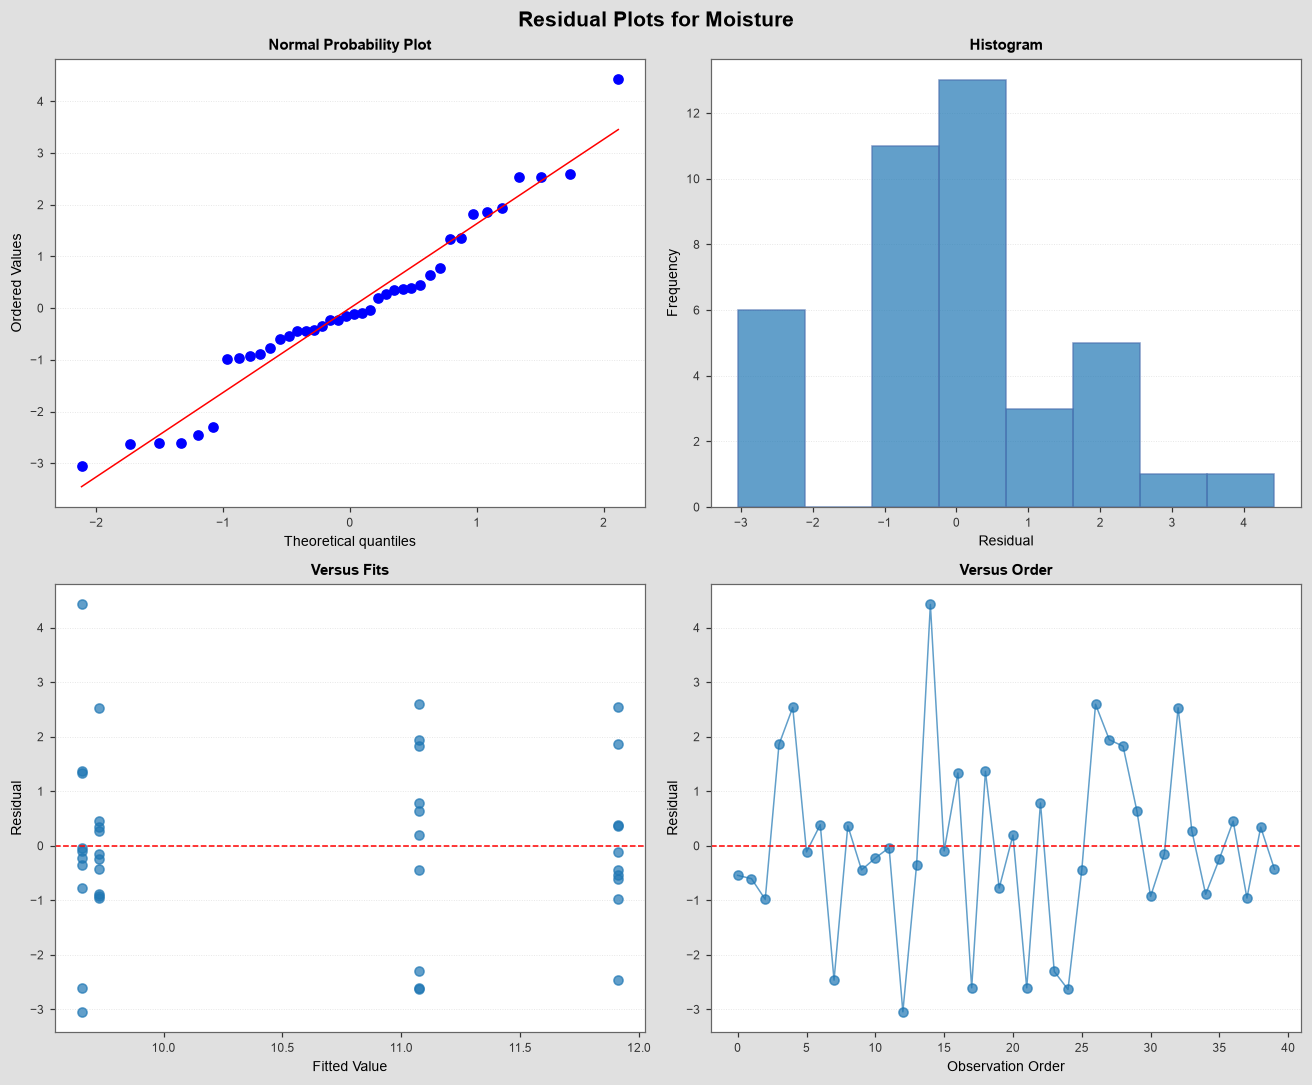

In [4]:
# Four-in-one residual plot
# Equivalent to Minitab: Graph > Residual plots > Four in one

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal Probability Plot (top left)
probplot(residuals, dist='norm', plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# 2. Histogram (top right)
axes[0, 1].hist(residuals, bins=8, edgecolor=ms.HIST_EDGE, alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram')

# 3. Residuals vs Fitted (bottom left)
axes[1, 0].scatter(fitted, residuals, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# 4. Residuals vs Order (bottom right) - the line graph
axes[1, 1].plot(range(len(residuals)), residuals, 'o-', alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for Moisture', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Check 1: Normality Assumption

We check this in the **probability plot**.

**Question:** Are the residuals normally distributed?

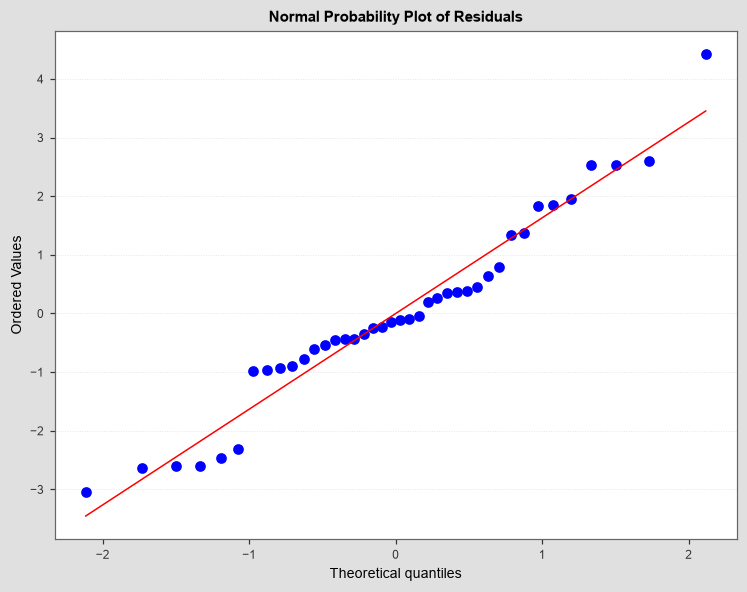

NORMALITY CHECK

Are the residuals normally distributed?

Looking at the probability plot:
  - Points follow the straight line
  - No systematic deviations

Answer: YES, they are normally distributed.


In [5]:
# Check normality
fig, ax = plt.subplots(figsize=(8, 6))
probplot(residuals, dist='norm', plot=ax)
ax.set_title('Normal Probability Plot of Residuals')
plt.show()

print('NORMALITY CHECK')
print('=' * 60)
print()
print('Are the residuals normally distributed?')
print()
print('Looking at the probability plot:')
print('  - Points follow the straight line')
print('  - No systematic deviations')
print()
print('Answer: YES, they are normally distributed.')

---

## Check 2: Outliers and Irregularities

We check this in the **line graph** (Residuals vs Order).

**Question:** Are there any outliers or strange patterns present?

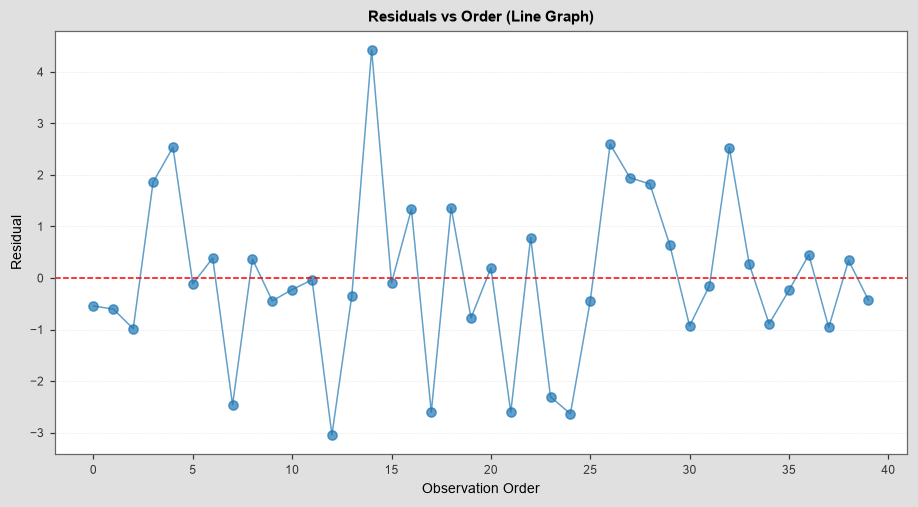

OUTLIERS AND PATTERNS CHECK

Are there any outliers or strange patterns present?

Looking at the line graph:
  - No extreme values (outliers)
  - No systematic patterns
  - Residuals randomly scattered around zero

Answer: NO outliers or strange patterns present.


In [6]:
# Check for outliers and patterns
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(residuals)), residuals, 'o-', alpha=0.7)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Observation Order')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Order (Line Graph)')
plt.show()

print('OUTLIERS AND PATTERNS CHECK')
print('=' * 60)
print()
print('Are there any outliers or strange patterns present?')
print()
print('Looking at the line graph:')
print('  - No extreme values (outliers)')
print('  - No systematic patterns')
print('  - Residuals randomly scattered around zero')
print()
print('Answer: NO outliers or strange patterns present.')

---

## Conclusion: Assumptions Satisfied

| Check | Result |
|-------|--------|
| Normally distributed residuals? | Yes |
| No outliers or irregularities? | Yes |

**Both assumptions are satisfied.**

This means the original ANOVA analysis is **valid**.

---

## What If Assumptions Are Violated?

If the residual analysis shows:
- Residuals are **NOT normally distributed** (probability plot shows deviations)
- **Outliers** are present in the line plot

Then the assumptions of the ANOVA are **violated**.

This implies that the conclusions from Step 2 would **not be valid** (or at least not very precise).

**Solution:** Perform a **Kruskal-Wallis analysis** instead.

---

## Summary: The Complete ANOVA Process

ANOVA is a technique to test whether a categorical influence factor (X) has a significant effect on a numerical Y.

| Step | Action | Key Output |
|------|--------|------------|
| **1** | Organize your data | X and Y in separate columns |
| **2** | Run the analysis | P-value (significance), R-squared (importance) |
| **3** | Validate conclusions | Check residuals for normality and outliers |

**If assumptions are violated → Use Kruskal-Wallis instead.**